# A gap, a run, a reversal — does the "breakaway" candle really break away? 🕳️
### The five-candle breakaway pattern — a chart shape that looks unmistakable and trades almost nothing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Works_both_directions_equally%3F: Busted](https://img.shields.io/badge/Works_both_directions_equally%3F-Busted-8b949e?style=flat-square)

Chartists love this one: a stock is falling, it **gaps down** one morning, keeps falling for two more days — then a big **reversal candle** shows up and closes *back through the gap*, as if the whole down-leg never happened. The story writes itself: the sellers who chased the gap are now underwater, the buyers who waited are vindicated, and the trend is supposedly over. Works upside-down too, in an uptrend.

That's the claim we test: **the gap-then-run-then-reversal shape marks the end of the trend it interrupted.** Six independent things have to line up for this pattern to even *exist* — which is exactly why it turns out to be almost too rare to trust.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the symmetry check? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY + 60 long-listed large-caps, ~25 years, yfinance daily bars. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from breakaway_candles import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'years': 25.0, 'n_names': 61, 'n_bars': 383080, 'n_loose': 44, 'n_strict': 5, 'n_bullish': 27, 'n_bearish': 17, 'bonferroni_crit': 2.5, 'combined': {1: {'n': 44, 'mean': -57.1, 'win': 43.2, 'base': -0.2, 'delta': -56.8, 't': -2.16, 'p': 0.993, 'net': -67.1}, 5: {'n': 44, 'mean': 13.6, 'win': 43.2, 'base': 1.1, 'delta': 12.5, 't': 0.24, 'p': 0.409, 'net': 3.6}, 10: {'n': 44, 'mean': 113.6, 'win': 63.6, 'base': 0.4, 'delta': 113.2, 't': 1.44, 'p': 0.07, 'net': 103.6}, 20: {'n': 44, 'mean': 325.8, 'win': 56.8, 'base': 6.7, 'delta': 319.1, 't': 2.39, 'p': 0.002, 'net': 315.8}}, 'strict': {1: {'n': 5, 'mean': -168.2, 'delta': -168.0, 'p': 0.993}, 5: {'n': 5, 'mean': -318.6, 'delta': -319.5, 'p': 0.979}, 10: {'n': 5, 'mean': -82.2, 'delta': -82.5, 'p': 0.64}, 20: {'n': 5, 'mean': 587.7, 'delta': 581.1, 'p': 0.041}}, 'bullish': {1: {'n': 27, 'mean': -116.2, 'base': 2.8, 'delta': -119.0, 't': -3.43, 'p': 1.0}, 5: {'n': 27, 'mean': 42.2, 'base': 27.7, 'delta': 14.5, 't': 0.19, 'p': 0.414}, 10: {'n': 27, 'mean': 256.4, 'base': 55.5, 'delta': 200.9, 't': 2.15, 'p': 0.026}, 20: {'n': 27, 'mean': 670.8, 'base': 120.0, 'delta': 550.8, 't': 3.33, 'p': 0.001}}, 'bearish': {1: {'n': 17, 'mean': 36.8, 'base': -2.6, 'delta': 39.4, 't': 1.39, 'p': 0.096}, 5: {'n': 17, 'mean': -31.9, 'base': -19.6, 'delta': -12.3, 't': -0.18, 'p': 0.567}, 10: {'n': 17, 'mean': -113.2, 'base': -42.5, 'delta': -70.6, 't': -0.57, 'p': 0.743}, 20: {'n': 17, 'mean': -222.1, 'base': -81.5, 'delta': -140.6, 't': -0.93, 'p': 0.814}}, 'best_worst': [('BDX', '2002-06-11', '2002-06-17', -1792.7), ('BDX', '2011-08-17', '2011-08-23', -598.1), ('LOW', '2002-07-18', '2002-07-24', 1584.6), ('DIS', '2025-04-03', '2025-04-09', 1821.9), ('CAT', '2010-08-23', '2010-08-27', 2026.0)], 'syn_null_mean': 0.58, 'syn_null_sd': 0.9, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_edge02_t': 4.43, 'syn_edge04_t': 7.96, 'fp_panel': '9693c3ea7807', 'fp_spy': '85f86a841de4'}


real cache present: True | names: 61


## The answer first

| Question | Answer |
|---|---|
| Does the breakaway shape mark a real reversal? | **No — or at least, we can't prove it.** Across **44** confirmed breakaways (both directions pooled) over 61 names and 25 years, no forward horizon (1/5/10/20 days) clears the statistical bar once you correct for testing four horizons at once. |
| How rare is it? | **Very.** 27 bullish + 17 bearish events in a quarter-century across 61 stocks — about **once every 35 ticker-years**. The stricter, textbook-faithful version fires only **5** times, total. |
| Does it at least work one direction? | **Only on paper, and only if you don't ask hard questions.** The bullish side alone *looks* significant at 20 days — until you notice its first day is a sharp loss, and its best trades cluster on famous market-crash bottoms rather than a stock-specific signal. |
| What about the bearish (short) version? | **Nothing.** Every horizon is statistically indistinguishable from noise, and three of four point estimates are *negative* — the opposite of what the pattern claims. |

> A shape the eye recognizes instantly, a force the tape refuses to obey.

## 1 · The claim

> *"A long candle in the direction of the trend, a gap that opens even further that way, two more days pressing the move, and then — a long candle slams back through the gap. That's a breakaway: the last gasp of the old trend, and the start of the new one."*

It's in every candlestick textbook (Nison's own phrase is that the reversal candle "closes within the area of the window" — it erases the last leg of the run). The gap is supposed to show conviction; the reversal candle is supposed to show that conviction was wrong.

## 2 · So what?

If real, this is a free, mechanical early-warning system: spot the shape, take the reversal trade the next morning, and you're on the right side of a trend change before most of the market notices. Five-candle reversal patterns are exactly the kind of thing chart-pattern services sell subscriptions on — so it's worth asking, plainly: does the shape actually predict anything, or does the eye just like a clean picture?

## 3 · How would we even know?

- **The detector.** A downtrend (or uptrend) into the pattern, a long first candle, a *clean* gap that stays open, two candles running further, then a long reversal candle closing back through the gap-day's own high/low. We test the plain reading **and** a stricter, textbook-faithful cut side by side.
- **The comparison.** Not "did the stock go up" — but did it beat the **same trade** on an *ordinary* day already sitting in that same downtrend or uptrend, shape or no shape.
- **The correction.** Four forward windows (1/5/10/20 days) means four chances to get lucky — so the bar to clear moves up (Bonferroni).
- **The symmetry check.** The claim is bidirectional. If it's a real reversal force and not a story about up-markets drifting up, both the bullish *and* bearish version should work.

## 4 · The teardown — let's actually look

**First, the headline** — both directions pooled, the pre-registered test.

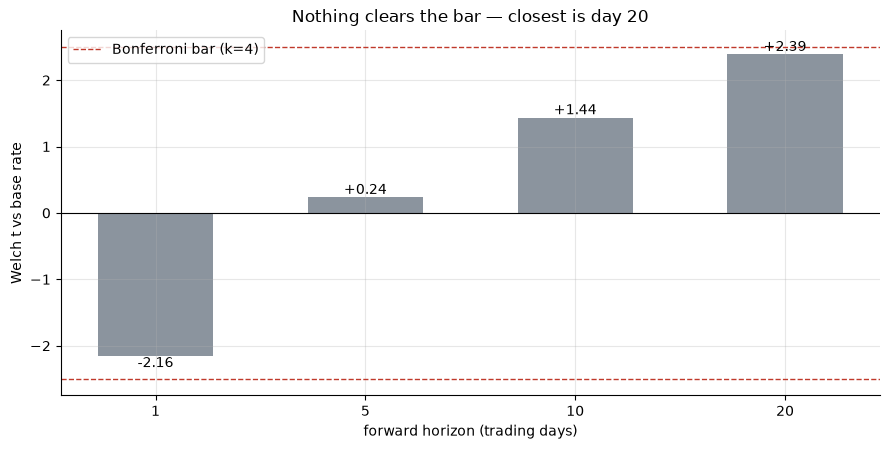

{1: -2.16, 5: 0.24, 10: 1.44, 20: 2.39}


In [2]:
if HAVE_REAL:
    res = st.combined_experiment(PANEL)
    hs = st.HORIZONS
    ts = [res['per_horizon'][h]['welch_t'] for h in hs]
    deltas = [res['per_horizon'][h]['delta_bps'] for h in hs]
else:
    hs = (1, 5, 10, 20)
    ts = [R['combined'][h]['t'] for h in hs]
    deltas = [R['combined'][h]['delta'] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
cols = [RED if abs(t) >= R['bonferroni_crit'] else GREY for t in ts]
ax.bar([str(h) for h in hs], ts, color=cols, width=.55)
for i, t in enumerate(ts): ax.annotate(f'{t:+.2f}', (i, t), ha='center',
    va='bottom' if t >= 0 else 'top')
ax.axhline(R['bonferroni_crit'], ls='--', c=RED, lw=1, label='Bonferroni bar (k=4)')
ax.axhline(-R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('forward horizon (trading days)'); ax.set_ylabel('Welch t vs base rate')
ax.set_title('Nothing clears the bar — closest is day 20')
ax.legend(); plt.tight_layout(); plt.show()
print({h: round(t, 2) for h, t in zip(hs, ts)})

With 44 confirmed breakaways (both directions), the closest any horizon gets to significance is day 20 (*t* = +2.39) — short of the Bonferroni-corrected bar of **2.50**. And day 1 is actually **negative** (*t* = -2.16): on average, the breakaway trade *loses* money on its very first session.

**Second, is it at least one-sided?** Split by direction:

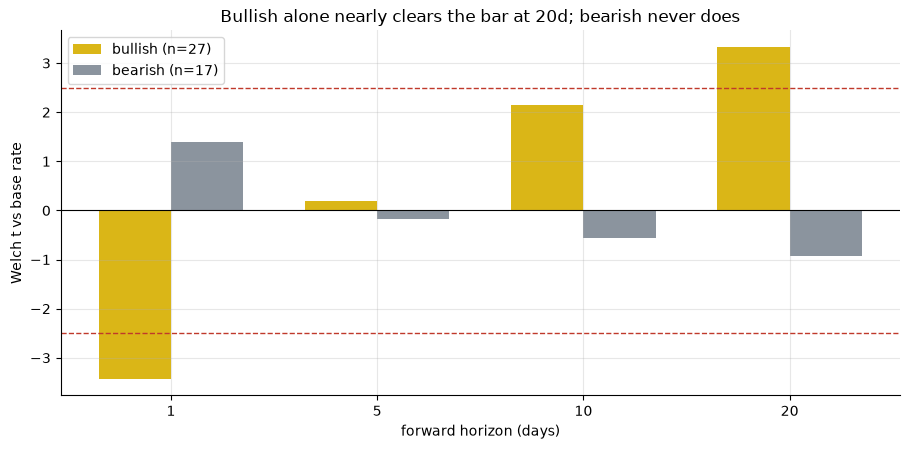

bullish {1: -3.43, 5: 0.19, 10: 2.15, 20: 3.33}
bearish {1: 1.39, 5: -0.18, 10: -0.57, 20: -0.93}


In [3]:
if HAVE_REAL:
    rb = st.run_experiment(PANEL, 'bullish')
    rr = st.run_experiment(PANEL, 'bearish')
    tb = [rb['per_horizon'][h]['welch_t'] for h in hs]
    tr = [rr['per_horizon'][h]['welch_t'] for h in hs]
else:
    tb = [R['bullish'][h]['t'] for h in hs]
    tr = [R['bearish'][h]['t'] for h in hs]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(hs)); w = 0.35
ax.bar(x - w/2, tb, width=w, color=AMBER, label=f"bullish (n={R['n_bullish']})")
ax.bar(x + w/2, tr, width=w, color=GREY, label=f"bearish (n={R['n_bearish']})")
ax.axhline(R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(-R['bonferroni_crit'], ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([str(h) for h in hs])
ax.set_xlabel('forward horizon (days)'); ax.set_ylabel('Welch t vs base rate')
ax.set_title('Bullish alone nearly clears the bar at 20d; bearish never does')
ax.legend(); plt.tight_layout(); plt.show()
print('bullish', {h: round(t,2) for h,t in zip(hs, tb)})
print('bearish', {h: round(t,2) for h,t in zip(hs, tr)})

The bullish side alone reaches *t* = **+3.33** at 20 days — past the bar! But look at day 1 for that *same* bullish side: *t* = **-3.43** — a sharp loss. And the bearish mirror, which should show the same effect shorting into strength, shows **nothing**: every horizon is under \|1.4\|, and 3 of 4 point estimates are outright negative.

**Third — is the bullish "signal" the candle, or the calendar?**

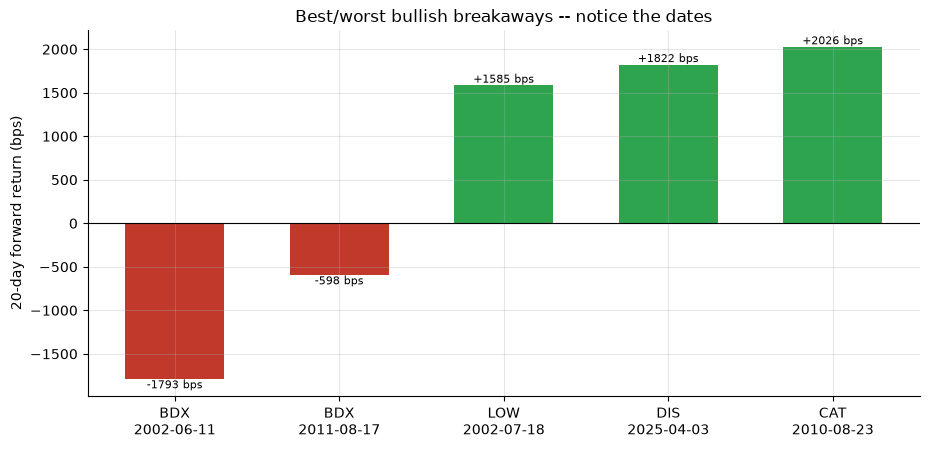

In [4]:
recs = R['best_worst']
labels = [f"{t}\n{d0}" for t, d0, d1, r in recs]
vals = [r for t, d0, d1, r in recs]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
cols = [RED if v < 0 else GREEN for v in vals]
ax.bar(labels, vals, color=cols, width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.0f} bps', (i, v), ha='center',
    va='bottom' if v >= 0 else 'top', fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('20-day forward return (bps)')
ax.set_title('Best/worst bullish breakaways -- notice the dates')
plt.tight_layout(); plt.show()

LOW's best trade fires in **July 2002** (the post-dot-com bottom), DIS's fires in **April 2025** (the tariff-selloff bottom), and CAT's fires weeks after the **2010 correction low**. These aren't obviously about the *candle* — they're about the *calendar*: the pattern happened to fire near some of the most famous market-wide bounces of the last 25 years. That's not a stock-specific reversal signal; that's riding a handful of historic dip-buying opportunities and calling it a pattern.

## 5 · The verdict

- **Signal — None.** The pre-registered, bidirectional test never clears the corrected bar at any horizon; the one cell that nominally does (bullish, 20 days) fails its own day-1 reaction and its own "is it the candle or the calendar" check.
- **Tradability — Mirage.** 44 events over 61 stocks and 25 years is a curiosity, not a strategy. Costs aren't even the binding constraint — there just aren't enough trades to matter.
- **Works both directions equally? — Busted.** Bullish rides crash-bottom coincidences without certifying; bearish does nothing at all.

## 6 · Going further 🚪

- **Rarity is the real finding.** Six independent conditions (trend, long candle, clean gap, two-day run, long reversal candle, crossing back through the gap) almost never line up together — the pattern's own strictness is what starves it of a usable sample, long before any economic mechanism gets a chance to show up.
- **Sibling studies:** the [island reversal](../../417-island-reversal/) (a two-gap bracket, no run), [mind the gap](../../74-mind-the-gap/) (does *any* gap fill?) and the [ladder bottom](../../687-ladder-bottom/) (this study's closest structural cousin — a no-gap, one-directional five-candle figure) all land in the same place: chart patterns built from rare, compound conditions rarely survive contact with a large enough sample.

*Think the strict cut is onto something? The honest next step is more history or more names, not a looser detector — five events will never be enough to trust, no matter how good they look.*